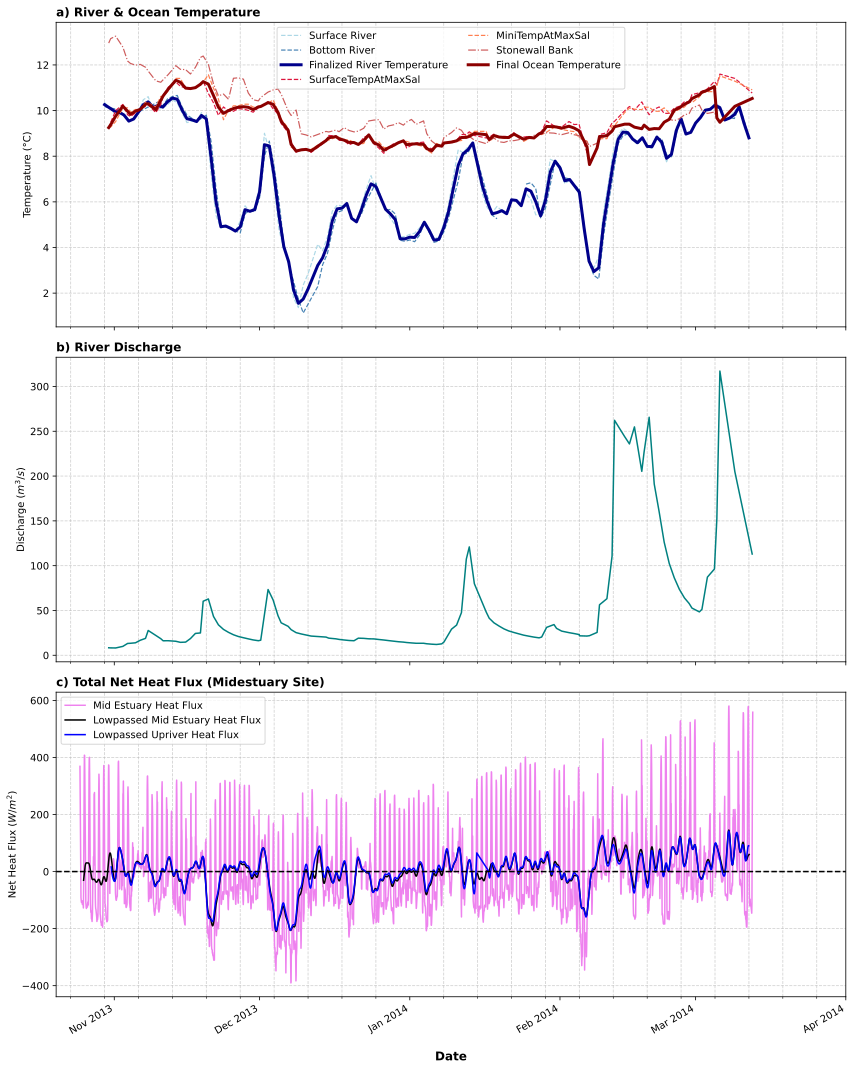

In [3]:
import datetime
import re
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import signal, stats
import scipy.io as sio

%config InlineBackend.figure_format = 'svg'

# --- Load Data ---
oceanDF = pd.read_csv('ocean_temperature13_14.csv', parse_dates=['DN'])
riverDF = pd.read_csv(
    'FINALIZED_river_temperature13_14.csv', parse_dates=['date_day']
)
midHeatFluxDF = pd.read_csv(
    'mid_heatflux_2013-2014.csv', parse_dates=['Tm (UTC)']
)
upHeatFluxDF = pd.read_csv(
    'upriver1314_heatflux.csv', parse_dates=['Tm (UTC)']
)

# --- Remove Spike and Surrounding Rows Directly (No NaNs, No Interpolation) ---
upHeatFluxDF = upHeatFluxDF.sort_values('Tm (UTC)').reset_index(drop=True)

# 1. Focus on January 2014 window
jan_2014_mask = (upHeatFluxDF['Tm (UTC)'] >= '2014-01-01') & (
    upHeatFluxDF['Tm (UTC)'] <= '2014-01-31'
)

# 2. Identify the spike indices
threshold = 200  # Adjust magnitude if needed
spike_indices = upHeatFluxDF[
    jan_2014_mask & (upHeatFluxDF['lowpass'].abs() > threshold)
].index

if len(spike_indices) > 0:
  # 3. Define wider buffer around spike to drop ringing/edge artifacts
  buffer_points = 10  # Increase buffer if spike tail extends further
  drop_start = max(0, spike_indices.min() - buffer_points)
  drop_end = min(len(upHeatFluxDF) - 1, spike_indices.max() + buffer_points)

  # Drop the entire slice of rows from the dataframe
  rows_to_drop = upHeatFluxDF.index[drop_start : drop_end + 1]
  upHeatFluxDF = upHeatFluxDF.drop(rows_to_drop).reset_index(drop=True)


# --- Find Global Min/Max Dates for Axis Alignment ---
min_date = min(
    riverDF['date_day'].min(),
    oceanDF['DN'].min(),
    midHeatFluxDF['Tm (UTC)'].min(),
)
max_date = max(
    riverDF['date_day'].max(),
    oceanDF['DN'].max(),
    midHeatFluxDF['Tm (UTC)'].max(),
)

# --- Setup Figure and Subplots ---
# Adjusted to 3 subplots instead of 4
fig, axs = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
fig.subplots_adjust(hspace=0.35)
# Set X-Axis Limits (Applied across all subplots via sharex=True)
axs[0].set_xlim(
    pd.Timestamp('2013-10-20 00:00:00'), pd.Timestamp('2014-04-01 00:00:00')
)

date_form = mdates.DateFormatter('%b %d %Y')

# -------------------------------------------------------------------------
# Subplot a) Combined River and Ocean Temperature
# -------------------------------------------------------------------------
# River Lines (Thinner/Dashed or Thick/Solid)
axs[0].plot(
    riverDF['date_day'],
    riverDF['surfaceRiver'],
    label='Surface River',
    color='lightblue',
    linestyle='--',
    linewidth=1.2,
)
axs[0].plot(
    riverDF['date_day'],
    riverDF['bottomRiver'],
    label='Bottom River',
    color='steelblue',
    linestyle='--',
    linewidth=1.2,
)
axs[0].plot(
    riverDF['date_day'],
    riverDF['EstimatedTemp'],
    label='Finalized River Temperature',
    color='darkblue',
    linewidth=3.0,
)

# Ocean Lines (Thinner/Dashed or Thick/Solid)
axs[0].plot(
    oceanDF['DN'],
    oceanDF['SurfaceTemp'],
    label='SurfaceTempAtMaxSal',
    color='crimson',
    linestyle='--',
    linewidth=1.2,
)
axs[0].plot(
    oceanDF['DN'],
    oceanDF['Temperature'],
    label='MiniTempAtMaxSal',
    color='coral',
    linestyle='--',
    linewidth=1.2,
)
axs[0].plot(
    oceanDF['DN'],
    oceanDF['dailyAverage'],
    label='Stonewall Bank',
    color='indianred',
    linestyle='-.',
    linewidth=1.2,
)
axs[0].plot(
    oceanDF['DN'],
    oceanDF['AvgEstimatedTemp'],
    label='Final Ocean Temperature',
    color='darkred',
    linewidth=3.0,
)

axs[0].set_title(
    'a) River & Ocean Temperature', loc='left', fontsize=12, fontweight='bold'
)
axs[0].set_ylabel('Temperature (°C)')
axs[0].legend(
    loc='upper center', ncol=2
)  # Two-column layout prevents legend overflow

# -------------------------------------------------------------------------
# Subplot b) River Discharge
# -------------------------------------------------------------------------
axs[1].plot(oceanDF['DN'], oceanDF['fRate'], color='teal', linewidth=1.5)

axs[1].set_title(
    'b) River Discharge', loc='left', fontsize=12, fontweight='bold'
)
axs[1].set_ylabel('Discharge ($m^3/s$)')

# -------------------------------------------------------------------------
# Subplot c) Total Net Heat Flux
# -------------------------------------------------------------------------
axs[2].plot(
    midHeatFluxDF['Tm (UTC)'],
    midHeatFluxDF['Qnet'],
    color='violet',
    linewidth=1.5,
)
axs[2].plot(
    midHeatFluxDF['Tm (UTC)'],
    midHeatFluxDF['lowpass'],
    color='black',
    linewidth=1.5,
)
axs[2].plot(
    upHeatFluxDF['Tm (UTC)'],
    upHeatFluxDF['lowpass'],
    color='blue',
    linewidth=1.5,
)

axs[2].axhline(0, color='black', linestyle='--', linewidth=1.5, zorder=10)
axs[2].legend(
    [
        'Mid Estuary Heat Flux',
        'Lowpassed Mid Estuary Heat Flux',
        'Lowpassed Upriver Heat Flux',
    ],
    loc='upper left',
    ncol=1,
)

axs[2].set_title(
    'c) Total Net Heat Flux (Midestuary Site)',
    loc='left',
    fontsize=12,
    fontweight='bold',
)
axs[2].set_ylabel('Net Heat Flux ($W/m^2$)')

# -------------------------------------------------------------------------
# Axis Formatting, Rotation, and Timeline Synchronization
# -------------------------------------------------------------------------
axs[2].set_xlabel('Date', fontsize=12)
axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()

# Set 7-day minor ticks for vertical gridlines across all subplots
for ax in axs:
  ax.grid(True, which='major', axis='y', linestyle='--', alpha=0.6)

  # 7-day interval for minor vertical gridlines along the x-axis
  ax.xaxis.set_minor_locator(mdates.DayLocator(interval=7))
  ax.grid(True, which='minor', axis='x', linestyle='--', alpha=0.6)

axs[2].set_xlabel('Date', fontweight='bold', labelpad=15)

# Display the plot
plt.tight_layout()
plt.show()